<a href="https://colab.research.google.com/github/MamoMGD1/ML_101/blob/main/notebooks/Section00_Building_Foundations/Chapter02_Data_Preprocessing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **PREPROCESSING A DATASET**

> “A model is only as good as the data you feed it.”

Before we even **touch** a machine learning algorithm, there's a battlefield of challenges waiting in the data itself. Raw datasets — no matter how well-documented or structured — are rarely ready to be thrown into a model. They’re messy, inconsistent, biased, incomplete, or sometimes just plain misleading.

Imagine this:
You’ve built a brilliant neural network architecture... but your training data contains missing values, mismatched categories, skewed distributions, and irrelevant features. The result? A **confused model** making poor predictions — not because it’s dumb, but because the data never gave it a fair chance.

#### **In this notebook, we dive into:**

* The **common issues** that plague real-world datasets
* How to **detect** these issues early
* The **tools and techniques** to clean, transform, and prepare your data
* Why good preprocessing can **outperform** fancy models trained on messy inputs

Whether you're working with spreadsheets, databases, or sensor streams, mastering **data preprocessing** is the key to unlocking reliable machine learning.

> *Remember: If data is the fuel of AI, preprocessing is the refinery.*

## **Loading Dataset**

In most of our projects, we will load datasets from the **Kaggle website**, just like we did here. After downloading, we sometimes **rename columns** or **translate values** to make them easier to understand. This step is not strictly necessary but can make the dataset clearer for us to work with—in this case, the dataset was originally in Turkish (on different house prices in Türkiye), so we translated both the column names and some of the values. Let's suppose that we want to train an AI model on this dataset so that it can predict a house's price from its features.

The very first thing we should always do is **look at the head of the DataFrame** (the first few rows). This quick inspection helps us understand what we’re dealing with. Right away, we can notice some important issues:

- The dataset contains many **NaN values**, which means there are missing or blank entries.  
- A lot of columns are stored as **strings**, even when they represent numbers (e.g., `"20+"`, `"3rd Floor"`).  
- There are many other inconsistencies that make this dataset **messy and difficult to work with**.

And that’s exactly why we chose it: the **House Prices in Türkiye** dataset is full of real-world problems. It forces us to practice **data cleaning and preprocessing**, which are essential skills in data science.

In [211]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Download the dataset from Kaggle
path = kagglehub.dataset_download("cabbar14ylnce/trkiye-home-price-data")

# Change to pandas dataframe
df = pd.read_csv(f'{path}/home_price.csv')

# Replace Turkish words with English translations
def replace_words(text, repl_dict):
    if isinstance(text, str):  # Only process strings
        for old_word, new_word in repl_dict.items():
            text = text.replace(old_word, new_word)  # Case-sensitive replacement
        return text
    return text

# Define dictionary of words to translate
value_translations = {"Çatı Katı": "Roof Floor", "Kat": "Floor", "Yüksek Giriş": "High Ground Floor", "Düz Giriş (Zemin)": "Ground Floor", "Bahçe": "Garden", "Çatı Dubleks": "Roof Duplex", "Müstakil": "Detached", "Villa Tipi": "Villa Type", "Bahçe Dublex": "Garden Duplex", "Kot": "Basement", "Bodrum": "Basement", "Yeni": "New", "21 Ve Üzeri": "21+", "Kombi Doğalgaz": "Gas Combi Boiler", "Yerden Isıtma": "Underfloor Heating", "Klimalı": "Air Conditioned", "Merkezi Doğalgaz": "Central Gas Heating", "Sobalı": "Stove Heated", "Merkezi (Pay Ölçer)": "Central (Metered) Heating", "Isıtma Yok": "No Heating", "Kat Kaloriferi": "Floor Heating", "Doğalgaz Sobalı": "Gas Stove Heated", "Diğer": "Other", "Merkezi Kömür": "Central Coal Heating", "Jeotermal": "Geothermal", "Güneş Enerjisi": "Solar Energy", "Boş": "Empty", "Eşyalı": "Furnished", "Mülk Sahibi Oturuyor": "Owner Occupied", "Kiracı Oturuyor": "Tenant Occupied", "Bilinmiyor": "Unknown", "Uygun": "Suitable", "Var": "Available", "Yok": "Not Available", "Floor Mülkiyeti": "Condominium Ownership", "Floor İrtifakı": "Construction Servitude", "Detached Tapulu": "Individual Title Deed", "Arsa Tapulu": "Land Title Deed", "Hisseli Tapu": "Shared Title Deed"}
column_translations = [ "Net_Square_M", "Gross_Square_M", "N_Rooms", "Located_Floor", "Furniture_Status", "Building_Age", "Heating_Type", "Price", "City", "N_Floors_in_Building", "Usage_Status", "Investment_Suitability", "Exchange", "Title_Deed", "N_Bathrooms"]

# Apply replacement to all values & columns
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].apply(replace_words, repl_dict=value_translations)
df.columns = column_translations

# Display first 10 rows of the DataFrame
display(df.head(10))

Using Colab cache for faster access to the 'trkiye-home-price-data' dataset.


,Net_Square_M,Gross_Square_M,N_Rooms,Located_Floor,Furniture_Status,Building_Age,Heating_Type,Price,City,N_Floors_in_Building,Usage_Status,Investment_Suitability,Exchange,Title_Deed,N_Bathrooms
0,120,150.0,4.0,4.Floor,Furnished,21+,Gas Combi Boiler,950000.0,adana,6,Empty,NaN,Available,Condominium Ownership,1.0
1,100,125.0,4.0,3.Floor,Empty,4,Gas Combi Boiler,1250000.0,adana,10,Empty,NaN,Available,NaN,1.0
2,89,95.0,3.0,4.Floor,Empty,0 (New),Gas Combi Boiler,1750000.0,adana,14,Empty,Suitable,Available,NaN,1.0
3,40,55.0,2.0,6.Floor,Empty,0 (New),Gas Combi Boiler,1300000.0,adana,14,Empty,Suitable,Not Available,NaN,1.0
4,140,150.0,4.0,Ground Floor,Empty,5-10,Air Conditioned,1700000.0,adana,4,Empty,Suitable,Not Available,Condominium Ownership,1.0
5,40,55.0,2.0,12.Floor,Empty,5-10,Air Conditioned,765000.0,adana,13,Tenant Occupied,NaN,NaN,Condominium Ownership,1.0
6,90,110.0,3.0,2.Floor,NaN,0 (New),Gas Combi Boiler,1700000.0,adana,14,Empty,Suitable,NaN,NaN,1.0
7,180,750.0,5.0,NaN,Empty,16-20,Air Conditioned,3950000.0,adana,2,Owner Occupied,Suitable,NaN,NaN,1.0
8,105,145.0,4.0,8.Floor,NaN,4,Gas Combi Boiler,1995000.0,adana,11,Empty,Suitable,NaN,Condominium Ownership,1.0
9,110,130.0,4.0,4.Floor,NaN,5-10,Gas Combi Boiler,2550000.0,adana,11,Empty,Suitable,Not Available,Construction Servitude,1.0


## **Handling Null (Missing) Values**

One of the most common issues in real-world datasets is **missing data** — also called *null values*, *NaNs*, or *blanks*. This can happen when inputs are left empty, sensors fail, or some information simply doesn’t apply to every case.  

### **How to detect missing values**
- Visually in spreadsheets (empty cells).
- In code: with Pandas functions like `.isnull()` or `.isna()`.

### **How to handle missing values**
There is no single “correct” way — it depends on the situation. Here are the main strategies:

1. **Drop rows or columns**  
   - **Rows** → Drop when only a **small fraction** of rows have missing values.  
     - Example: If only 5 out of 10,000 rows are missing age values, you can safely remove those rows.  
   - **Columns** → Drop when a column has **too many missing values** (so it’s not reliable anymore).  
     - Example: If 80% of entries in the age column are blank, it’s better to drop that column.  

2. **Fill (impute) with statistics**  
   - **Numeric columns**:  
     - Use the **mean** if the data is fairly balanced and has no extreme outliers.  
     - Use the **median** if there are **outliers** (it’s more robust and less misleading).  
   - **Categorical columns**:  
     - Use the **mode** (most frequent value).  
   - Example: If a few house prices are missing, filling with the median makes more sense than the mean if some very expensive mansions skew the average.

3. **Fill with fixed or logical values**  
   - Use when missing means something specific.  
   - Example: A “Furnished” column that’s blank could be replaced with `"Unknown"` or `"Not Available"`.  

4. **Advanced (model-based imputation)**  
   - Predict missing values using other features (outside of this syllabus).  
   - Example: Predict a missing salary based on age, education, and job title.  

---

## **Code Insights**

When dealing with missing data, we should always think in terms of **balance**:  

- We **can’t just remove all columns** that have null values — they are collected with effort and might carry important information.  
- But we also **can’t keep everything** and blindly fill huge amounts of missing values, because that means we are **artificially inventing too much data**, which can distort our analysis.  

The solution is to look for an **equilibrium**.  

In our dataset of ~20,000 samples, some columns have large amounts of missing values. For instance:  
- The **`Title_Deed`** column has **10,566 missing values** (more than half of the dataset).  
- Filling such a column would mean inventing values for nearly 50% of the data — which is unreliable.  

So we removed two columns (**`Furniture_Status`** and **`Title_Deed`**) that had **more than 30% missing values**. This is a reasonable trade-off: we keep most of the dataset, but avoid unreliable features.  

Also, **personal judgment matters**: for example, I personally don’t believe the type of title deed strongly affects house price prediction, so removing it feels even more justified.  

- **Numeric columns** → filled with the **median** (robust to outliers).  
- **Categorical columns** → filled with the **mode** (most frequent value).  

Finally, when we check again, we confirm that **no missing values remain**.  

> Note: After filling missing values, it’s also a good practice to **drop duplicate rows** if they exist. Duplicate samples can bias our calculations and models.

In [212]:
print("Shape of the dataset (samples × features): ", df.shape)

# Check for missing values in each column
print("Number of missing (null) values per column:")
display(df.isnull().sum())

# Drop columns with too many (more than 30%) missing values
df_cleaned = df.dropna(axis=1, thresh=df.shape[0] - 0.3*df.shape[0])

print("\nDropped columns with too many missing values:",set(df.columns) - set(df_cleaned.columns))

# Fill numeric columns with their median
numeric_cols = df_cleaned.select_dtypes(include='number').columns
df_cleaned.loc[:,numeric_cols] = df_cleaned[numeric_cols].fillna(df_cleaned[numeric_cols].median())

# Fill categorical columns with their mode
categorical_cols = df_cleaned.select_dtypes(include='object').columns
for col in categorical_cols:
    df_cleaned.loc[:,col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

# Remove duplicate values if any
df_cleaned = df_cleaned.drop_duplicates()

# Final check: Are there still any null values?
print("\nDuplicate values left: ", df_cleaned.duplicated().sum())
print("\nNull values after cleaning:")
display(df_cleaned.isnull().sum())

Shape of the dataset (samples × features):  (20326, 15)
Number of missing (null) values per column:


,0
Net_Square_M,0
Gross_Square_M,0
N_Rooms,260
Located_Floor,2297
Furniture_Status,7398
Building_Age,0
Heating_Type,0
Price,0
City,0
N_Floors_in_Building,0



Dropped columns with too many missing values: {'Title_Deed', 'Furniture_Status'}

Duplicate values left:  0

Null values after cleaning:


,0
Net_Square_M,0
Gross_Square_M,0
N_Rooms,0
Located_Floor,0
Building_Age,0
Heating_Type,0
Price,0
City,0
N_Floors_in_Building,0
Usage_Status,0


## **Feature Selection**

In real-world machine learning projects, not every feature (column) is useful or reliable. Some features may add noise, redundancy, or even mislead the model. Careful **feature selection** helps us build models that are simpler, faster, and often more accurate.  

In this project, we started with **all available features**, but throughout the **data preprocessing pipeline** we will evaluate each feature’s relevance and quality.

### **When to remove a feature**

- **Too many missing values** → If more than half the entries in a column are missing, filling them would create artificial data.  
Example: In our dataset, `Title_Deed` had over 10,000 missing values, so we dropped it.  

- **High cardinality categorical features** → Columns with too many unique categories are hard to encode and may not generalize well.  
Example: A “Patient Name” column in patients dataset could have thousands of unique values, making them impractical for modeling.  

- **Constant or near-constant features** → Features with little to no variation don’t provide useful information.  
Example: A “Currency” column in a dataset where all entries are in USD adds no predictive value.  

- **Highly correlated features** → If two columns carry the same information, one can be removed to avoid redundancy.  
Example: “Height in m” and “Height in ft” are perfectly correlated; keeping both doesn’t give us new info.

- **Identifier-like features** → Columns that are unique per sample but irrelevant to prediction should be discarded.  
Example: “Patient ID” or “Listing ID” doesn’t influence final results, and could confuse the model.  

### **How we select features**

We’ll use a combination of:  
- **Statistical checks** (variance, missing values, correlation),  
- **Model-based insights** (feature importance),  
- **Domain knowledge and logic** (understanding which features make sense).  

As we move through preprocessing and analysis, you’ll see some features being **excluded step by step**. This iterative pruning is the essence of **feature selection**, and it’s a core skill for building effective ML models.

## **Encoding Categorical Variables**

Machine learning models work best with numerical data — they simply don’t understand text. But real-world datasets often include **categorical features** like `"color"`, `"gender"`, or `"country"`.

To use these features in a model, we need to **convert them into numbers**, and that's what *encoding* is all about.

There are three common ways to do this:

- **Label Encoding:**  
  Each category is assigned a unique integer.  
  Example: `{"bad": 0, "medium": 1, "good": 2}`.  
  - Works when categories have **natural order** (ordinal data), like quality levels, rankings, education stages.  
  - Problem: For nominal data (like names or colors), the model might wrongly assume order or distance between values.  
    *Example:* If we encode names `{"Ahmad": 0, "Bashir": 1, "Zahra": 2}`, a model could mistakenly interpret `Zahra > Bashir > Ahmad`, which makes no sense.  

- **One-Hot Encoding:**  
  Creates a new binary (0/1) column for each possible category.  
  Example: If the column `Color` has categories `{"red", "blue", "green"}`, then we create three new features:  
  - `is_red` → `[1,0,0]`  
  - `is_blue` → `[0,1,0]`  
  - `is_green` → `[0,0,1]`  

  Now, instead of forcing an artificial order like *red < blue < green*, the model just knows whether each sample is red, blue, or green.  

  - Works best for **nominal data** (unordered categories, like colors, cities, or product types).  
  - Downside: If there are too many unique categories (high cardinality), one-hot encoding can blow up into hundreds or thousands of new features.  
    *Example:* A `City` column with 500 unique values would turn into 500 binary columns. In such cases, alternative encoding techniques (like target encoding or embeddings) might be more practical.

- **Target Encoding:**  
Replace each category with a number that reflects its relationship to the target variable.  
Example: Suppose we’re predicting house prices, and we have a `City` column:  
    `City = Ankara` → average price = 500k   
    `City = Istanbul` → average price = 1M   
    `City = Izmir` → average price = 700k   
    We replace the city names with these averages.  
    - Useful when categories are many and one-hot would explode in size.  
    - Risk of overfitting if used carelessly (model might “cheat” by memorizing target values).  

---

## **Code Insights**

We started by converting the `Building_Age` column into meaningful numbers. Ranges such as "5-10" were replaced by their average value (7.5), and open-ended values like "21+" were assigned the number 21. This way the column reflects a numerical measure of age, instead of being stuck as text.

For `Located_Floor`, every floor label was turned into an integer. A string like "3.Floor" became 3, "Ground Floor" became 0, and basements such as "Basement (-2)" were translated into negative numbers (-2 in this case). For values like "40+.Floor", we fixed them at 40. If a label could not be understood in a numerical way, we left it as NaN and dropped it later.

In `Heating_Type` and `City`, the number of categories was too large for one-hot encoding, so we used target encoding. This means each category was replaced with the average house price for that category. To avoid noisy or misleading averages, we removed rare categories with very few samples (< 100 houses.)

`Usage_Status` was simpler, since it only had three categories: "Empty", "Owner Occupied", and "Tenant Occupied". For this, we used one-hot encoding, creating three separate columns where the presence of each status is marked as 1 or 0.

The `Investment_Suitability` column was dropped entirely. The majority of its values were “Unknown”, which meant the information was unreliable and would have added more confusion than value.

The `Exchange` column was reduced to a binary variable: "Available" was mapped to 1 and "Not Available" to 0.

At the very end, we checked the dataset with `df_encoded.describe()`. This gave us a full statistical summary of the transformed data, but two points were the most important:  
- Every column has exactly 18,766 values, showing that there are no missing values left.  
- All 14 columns are now numerical, which is exactly the form we wanted from the beginning.

This does not mean the dataset is completely ready yet. What we have now is a consistent, numeric representation of the data, but there are still several important steps ahead before it can be modeled effectively.

In [213]:
# Display all the values in the categorical columns
for cat in categorical_cols:
    display(df_cleaned[cat].value_counts())

,count
Located_Floor,
2.Floor,5981
3.Floor,2980
1.Floor,2754
4.Floor,1893
High Ground Floor,1199
5.Floor,1153
Ground Floor,610
6.Floor,567
7.Floor,510


,count
Building_Age,
0 (New),6124
5-10,4445
21+,2535
11-15,1959
16-20,1472
4,1326
1,866
3,701
2,612


,count
Heating_Type,
Gas Combi Boiler,11842
Underfloor Heating,1773
Air Conditioned,1715
Central Gas Heating,1576
Stove Heated,848
Central (Metered) Heating,796
No Heating,457
Floor Kaloriferi,311
Doğalgaz Stove Heated,218


,count
City,
diyarbakir,1432
antalya,1429
denizli,1425
adana,1411
gaziantep,1404
kocaeli,1307
canakkale,943
eskisehir,938
bursa,837


,count
Usage_Status,
Empty,12393
Owner Occupied,4117
Tenant Occupied,3530


,count
Investment_Suitability,
Unknown,13590
Suitable,6450


,count
Exchange,
Not Available,15312
Available,4728


In [214]:
# Building_Age
def process_building_age(val):
    if isinstance(val, str):
        if '-' in val:  # ranges like "5-10"
            low, high = val.split('-')
            return (int(low) + int(high)) / 2
        elif '+' in val:  # "21+"
            return 21
        elif val.isdigit():  # "4", "2", etc.
            return int(val)
        elif val[0].isdigit():
            return int(val[0])
    return np.nan

df_encoded = df_cleaned.copy()
df_encoded['Building_Age'] = df_encoded['Building_Age'].apply(process_building_age)

# Located_Floor
def process_floor(val):
    if isinstance(val, str):
        # Handle basement floors like "Basement 3 (-3).Floor"
        if '(' in val and ')' in val:
            return int(val[val.find('(')+1:val.find(')')])

        # Handle "40+.Floor"
        if '+' in val:
            num = val.split('+')[0]
            return int(num)  # just take 40

        # Handle "1.Floor", "12.Floor"
        if val[0].isdigit():
            return int(val.split('.')[0])

        # Special named floors
        if "Ground Floor" in val:
            return 0
        if "High Ground Floor" in val:
            return 0.5
        if "Garden Floor" in val:
            return -0.5

    # Ambiguous ones → NaN
    return np.nan

df_encoded['Located_Floor'] = df_encoded['Located_Floor'].apply(process_floor)
df_encoded = df_encoded.dropna()

# Heating_Type (target encoding + drop small categories)
heating_counts = df_encoded['Heating_Type'].value_counts()
valid_heatings = heating_counts[heating_counts >= 100].index
df_encoded = df_encoded[df_encoded['Heating_Type'].isin(valid_heatings)]

heating_means = df_encoded.groupby('Heating_Type')['Price'].mean()
df_encoded['Heating_Type'] = df_encoded['Heating_Type'].map(heating_means)

# City (target encoding + drop small categories)
city_counts = df_encoded['City'].value_counts()
valid_cities = city_counts[city_counts >= 100].index
df_encoded = df_encoded[df_encoded['City'].isin(valid_cities)]

city_means = df_encoded.groupby('City')['Price'].mean()
df_encoded['City'] = df_encoded['City'].map(city_means)

# Usage_Status (one-hot encoding)
df_encoded = pd.get_dummies(df_encoded, columns=['Usage_Status'], prefix='Usage', dtype=int)

# Investment_Suitability (drop column)
df_encoded = df_encoded.drop(columns=['Investment_Suitability'])

# Exchange (binary mapping)
df_encoded['Exchange'] = df_encoded['Exchange'].map({'Not Available': 0, 'Available': 1})

# Final check
df_encoded.describe()

,Net_Square_M,Gross_Square_M,N_Rooms,Located_Floor,Building_Age,Heating_Type,Price,City,N_Floors_in_Building,Exchange,N_Bathrooms,Usage_Empty,Usage_Owner Occupied,Usage_Tenant Occupied
count,18766.000000,1.876600e+04,18766.000000,18766.000000,18766.000000,1.876600e+04,1.876600e+04,1.876600e+04,18766.000000,18766.00000,18766.000000,18766.000000,18766.000000,18766.000000
mean,150.815944,1.557197e+09,3.665272,2.823031,7.281307,4.496707e+06,4.534547e+06,4.534547e+06,5.279015,0.23468,1.481669,0.621390,0.201748,0.176862
std,1179.652692,2.133179e+11,1.085345,2.551623,7.427488,2.667652e+06,7.213525e+07,3.497860e+06,3.084727,0.42381,0.787228,0.485054,0.401316,0.381562
min,0.000000,2.000000e+00,1.000000,-4.000000,0.000000,2.315317e+06,2.000000e+04,1.484779e+06,1.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,90.000000,1.000000e+02,3.000000,1.000000,0.000000,3.837758e+06,1.626250e+06,2.666780e+06,3.000000,0.00000,1.000000,0.000000,0.000000,0.000000
50%,120.000000,1.300000e+02,4.000000,2.000000,7.500000,3.837758e+06,2.270000e+06,3.735983e+06,4.000000,0.00000,1.000000,1.000000,0.000000,0.000000
75%,149.000000,1.670000e+02,4.000000,4.000000,13.000000,3.837758e+06,3.250000e+06,5.007524e+06,6.000000,0.00000,2.000000,1.000000,0.000000,0.000000
max,110000.000000,2.922222e+13,12.000000,40.000000,21.000000,1.698208e+07,7.500000e+09,2.390232e+07,15.000000,1.00000,6.000000,1.000000,1.000000,1.000000


## **Feature Engineering**

While **feature selection** is about removing irrelevant or harmful features, **feature engineering** is about **creating new, more informative features** from the data we already have. This step is often what makes the biggest difference between an average model and a powerful one.

Good feature engineering combines:
- **Domain knowledge** (what makes sense in the real world),
- **Mathematical transformations**, and
- **Creativity** in representing the data.

### **Examples of feature engineering**
- **Combining existing columns**  
  *Example (Housing):* From `Net_Square_M` and `N_Rooms`, we can create “Square meters per room,” which gives a better sense of how spacious each room is.  
  *Example (Retail):* From `Unit Price` × `Quantity`, we can create `Total Transaction Value`.

- **Extracting information from text or dates**  
  *Example (Market):* From a `Sales Date`, we can extract `Month`, `Year`, or even `Is_Holiday_Season` to capture seasonal price fluctuations.

- **Creating interaction features**  
  *Example (Health):* From `Weight` and `Height`, we can create `BMI`.  
  *Example (Finance):* From `Income` and `Debt`, we can create `Debt-to-Income Ratio`.

- **Aggregating values**  
  *Example (Customer Data):* From all previous purchases of a customer, we can calculate their `Average Spend` or `Purchase Frequency`.  
  *Example (Weather Data):* From daily temperatures, we could create `7-day Rolling Average` to capture trends instead of just daily noise.

Most machine learning algorithms don’t automatically understand the *meaning* of raw data. By carefully engineering features, we’re essentially **feeding the model with clearer signals**.  

In fact, in many projects, **feature engineering has a bigger impact than the choice of algorithm** itself. Two teams using the same model can get drastically different results if one team invests more effort in creating meaningful features.

> Feature engineering is where **data meets creativity**. It’s often the step that separates a decent ML project from a truly insightful one.

---

## **Code Insights**

What we did here is called **feature engineering** — we created *synthetic features* by combining existing ones in non-trivial ways.  

Notice the difference: if we just made a `Net_Square_Ft` column by multiplying `Net_Square_M` by a constant, that would only be a **linear transformation**, and it wouldn’t add any new information (both features would end up almost perfectly correlated).  

But the features we’ve built — like `room_density` (rooms per square meter), `floor_ratio` (relative position in the building), or `bathroom_per_room` — are **non-linear combinations** of multiple columns. That makes them valuable, because they highlight aspects of the data that were *hidden* when looking at single columns in isolation.  

Think of it like writing a résumé: you may already mention you “led a team,” but when you **add a new section** in which you mention “I increased sales by 20% while leading that team,” you shine a spotlight on the part that really matters. These new features are our way of shining a spotlight for the model, drawing its attention to relationships that **we know** influence housing prices more directly.

In [215]:
df_featured = df_encoded.copy()

# Fill Net_Square_M of the homes that are 0 with their Gross_Square_M to avoid DivisionByZero
df_featured.loc[df_featured['Net_Square_M']==0, 'Net_Square_M'] = df_featured[df_featured['Net_Square_M']==0]['Gross_Square_M']

# Room Density
# How many rooms per square meter (space efficiency)
df_featured["Room_Density"] = df_featured["N_Rooms"] / df_featured["Net_Square_M"]

# Floor Ratio
# Position of the apartment relative to total floors in the building
# Example: 5th floor out of 10 → 0.5
df_featured["Floor_Ratio"] = df_featured["Located_Floor"] / df_featured["N_Floors_in_Building"]

# New Large Indicator
# Flag for properties that are both "new" (≤5 years) and "large" (≥149 sqm)
df_featured["New&Large"] = ((df_featured["Building_Age"] <= 5) &
                            (df_featured["Net_Square_M"] >= 149)).astype(int)

# Bathroom per Room
# Ratio of bathrooms to rooms — quality indicator
df_featured["Bathroom_Per_Room"] = df_featured["N_Bathrooms"] / df_featured["N_Rooms"]

# Net-to-Gross Ratio
# Measures efficiency of usable area vs. total area
df_featured["Net_To_Gross_Ratio"] = df_featured["Net_Square_M"] / df_featured["Gross_Square_M"]

# Quick Check
display(df_featured.head(10))

,Net_Square_M,Gross_Square_M,N_Rooms,Located_Floor,Building_Age,Heating_Type,Price,City,N_Floors_in_Building,Exchange,N_Bathrooms,Usage_Empty,Usage_Owner Occupied,Usage_Tenant Occupied,Room_Density,Floor_Ratio,New&Large,Bathroom_Per_Room,Net_To_Gross_Ratio
0,120,150.0,4.0,4.0,21.0,3.837758e+06,950000.0,3.172486e+06,6,1,1.0,1,0,0,0.033333,0.666667,0,0.250000,0.800000
1,100,125.0,4.0,3.0,4.0,3.837758e+06,1250000.0,3.172486e+06,10,1,1.0,1,0,0,0.040000,0.300000,0,0.250000,0.800000
2,89,95.0,3.0,4.0,0.0,3.837758e+06,1750000.0,3.172486e+06,14,1,1.0,1,0,0,0.033708,0.285714,0,0.333333,0.936842
3,40,55.0,2.0,6.0,0.0,3.837758e+06,1300000.0,3.172486e+06,14,0,1.0,1,0,0,0.050000,0.428571,0,0.500000,0.727273
4,140,150.0,4.0,0.0,7.5,4.193263e+06,1700000.0,3.172486e+06,4,0,1.0,1,0,0,0.028571,0.000000,0,0.250000,0.933333
5,40,55.0,2.0,12.0,7.5,4.193263e+06,765000.0,3.172486e+06,13,0,1.0,0,0,1,0.050000,0.923077,0,0.500000,0.727273
6,90,110.0,3.0,2.0,0.0,3.837758e+06,1700000.0,3.172486e+06,14,0,1.0,1,0,0,0.033333,0.142857,0,0.333333,0.818182
7,180,750.0,5.0,2.0,18.0,4.193263e+06,3950000.0,3.172486e+06,2,0,1.0,0,1,0,0.027778,1.000000,0,0.200000,0.240000
8,105,145.0,4.0,8.0,4.0,3.837758e+06,1995000.0,3.172486e+06,11,0,1.0,1,0,0,0.038095,0.727273,0,0.250000,0.724138
9,110,130.0,4.0,4.0,7.5,3.837758e+06,2550000.0,3.172486e+06,11,0,1.0,1,0,0,0.036364,0.363636,0,0.250000,0.846154


## **Outlier Detection**

Before scaling or modeling, we need to stop and think about **outliers** — values that stand far outside the normal range of our data.  

Take a look at the `describe()` summary two cells above:  

- `Gross_Square_M`: most values are below 200, but the maximum suddenly jumps to **2.9 × 10¹³**.  
- `Net_Square_M`: interquartile values (25% & 75%) cluster around **90–149**, but the maximum explodes to **110,000**.  
- `Price`: half the homes are around **2 million TL**, yet the max record claims **7.5 billion TL**.  

These aren’t just “big houses” — they are statistical outliers.  

---

### **What is an Outlier?**  
An **outlier** is a data point that does not follow the overall pattern of the dataset.  
Example: If most apartments are priced between **1M–4M TL**, but one is listed at **7.5B TL**, that point is an outlier, and we don't like it.  

### **How Do We Detect Outliers?**

There are two common approaches:  

1. **Statistical rules**  
   - **Z-score method**: Flag points with Z-score > 3 or < -3.  
   - **IQR (Interquartile Range)**: Flag points outside $Q1 - 1.5×IQR$ or $Q3 + 1.5×IQR$.  

2. **Visual inspection**  
   - **Box Plots**: Outliers appear as points outside the whiskers.  
   - **Scatter Plots**: Show data points that “float” far away from the main cluster.  
   - **Histogram Plots**: Show both “variation range” and “frequency” of the data.  

---

### **Why Do Outliers Matter?**

Outliers can **distort scaling and modeling**:  
- With **Min-Max Scaling**, one extreme value squashes all the other values into a tiny range.  
- With **Standardization**, extreme values inflate the standard deviation and drag the mean.  

This is why outlier detection is not optional — it’s a **crucial step** before scaling or training.  

> **In short**: Outliers are not always “wrong,” but they can **confuse our model** if left untreated. Our next step is to decide how to handle them: **remove, cap, or transform** — depending on the story they tell about the data.  

---

### **Code Insights**

When we first plot histograms of our features, many of them look “squashed” against one side, making the distributions unreadable. This happens because of a few extremely large values (outliers) stretching the x-axis.

Since binary features (0/1) can’t really have outliers by definition, we excluded them from this analysis. For the rest, the simplest approach was to **remove the top 1% of the largest values** in the features where the plots were unreadable. Importantly, we always check how many samples are dropped, because removing too many would hurt the dataset more than it helps. In our case, we lost **a total of 898 samples**, which was an acceptable trade-off for much clearer distributions.

Note that we did **not** trim features like `Heating_Type` or `City`, even though they contained extreme values. That’s because those “extremes” actually occurred quite frequently, and removing them would have thrown away too much useful data.

Finally, features like `Price` (long right tail) and `Net_To_Gross_Ratio` (long left tail) are very skewed, but their tails are not true outliers—they represent the natural spread of values. We will handle this skewness later with transformation techniques rather than trimming.

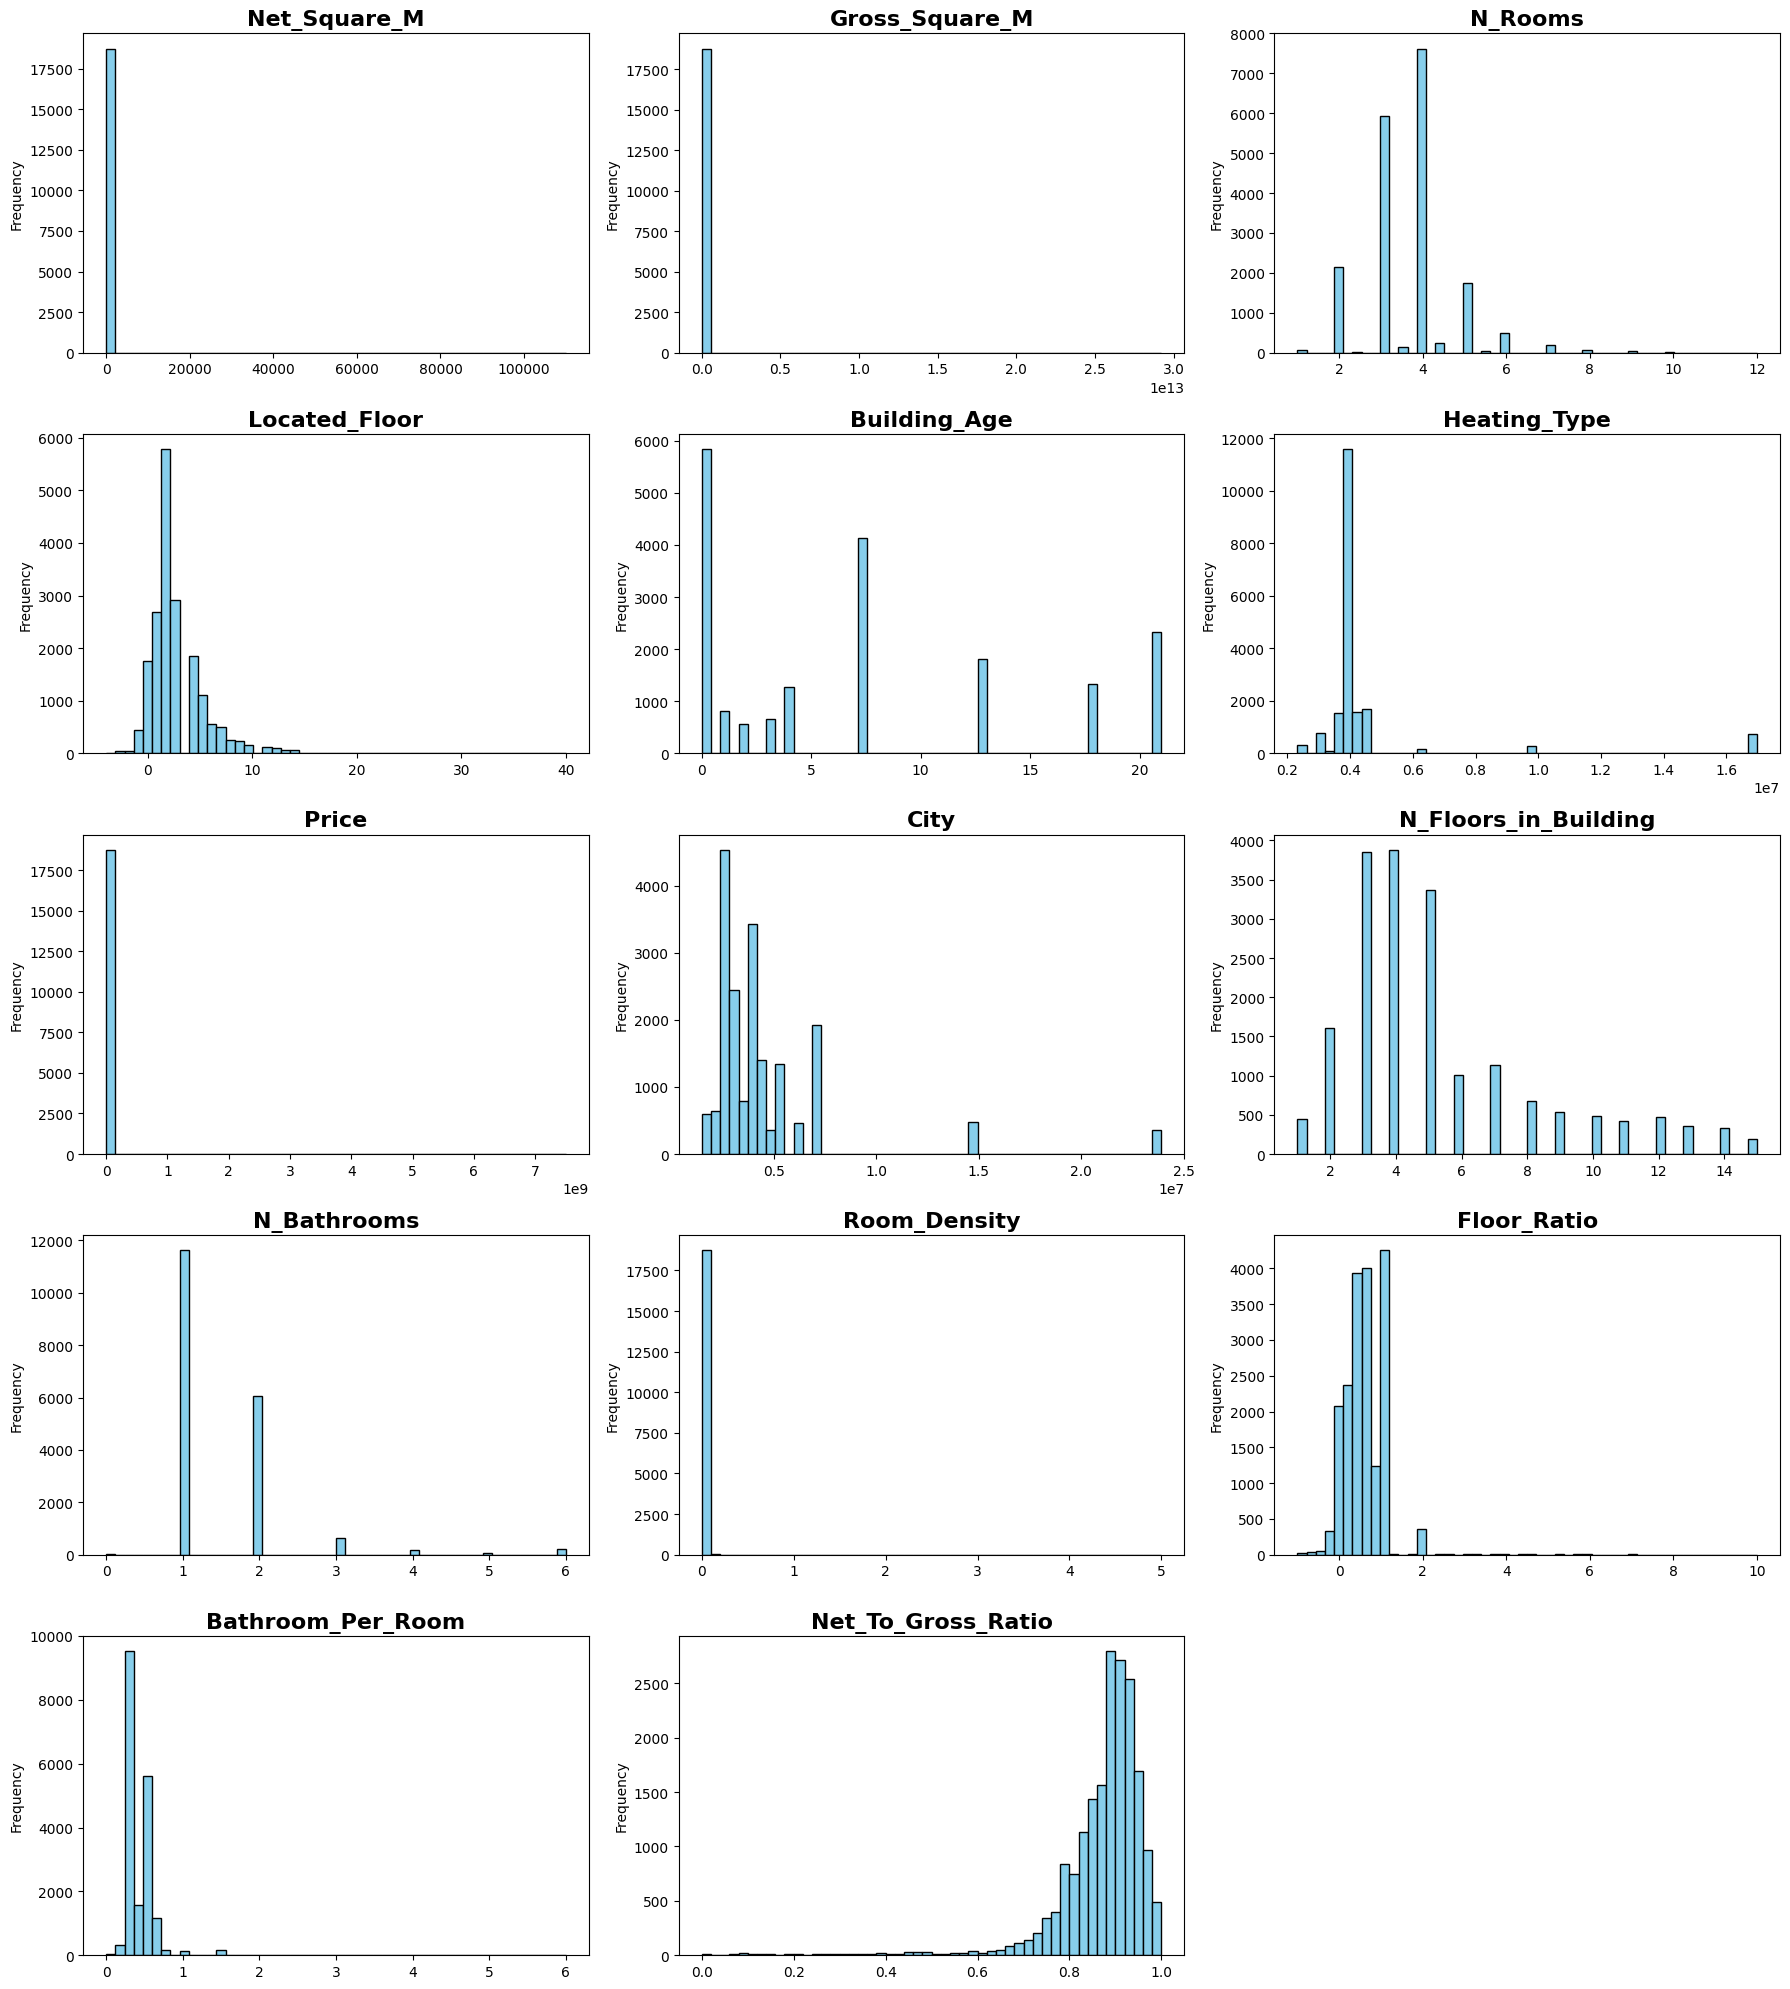

In [216]:
def plot_feature_distributions(df=df_featured, bins=50):
    # Take all non-binary numeric columns
    features = [col for col in df.columns if not set(df[col].unique()).issubset({0, 1})]

    n_features = len(features)
    n_cols = 3
    n_rows = (n_features + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
    axes = axes.flatten()

    for i, col in enumerate(features):
        df[col].plot(
            kind="hist",
            bins=bins,
            ax=axes[i],
            color="skyblue",
            edgecolor="black"
        )
        axes[i].set_title(col, fontsize=16, fontweight='bold')

    # Remove any unused subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()

plot_feature_distributions()

175 (top 1%) samples removed from Net_Square_M
186 (top 1%) samples removed from Gross_Square_M
181 (top 1%) samples removed from Price
160 (top 1%) samples removed from Room_Density
66 (top 1%) samples removed from Floor_Ratio
130 (top 1%) samples removed from Bathroom_Per_Room


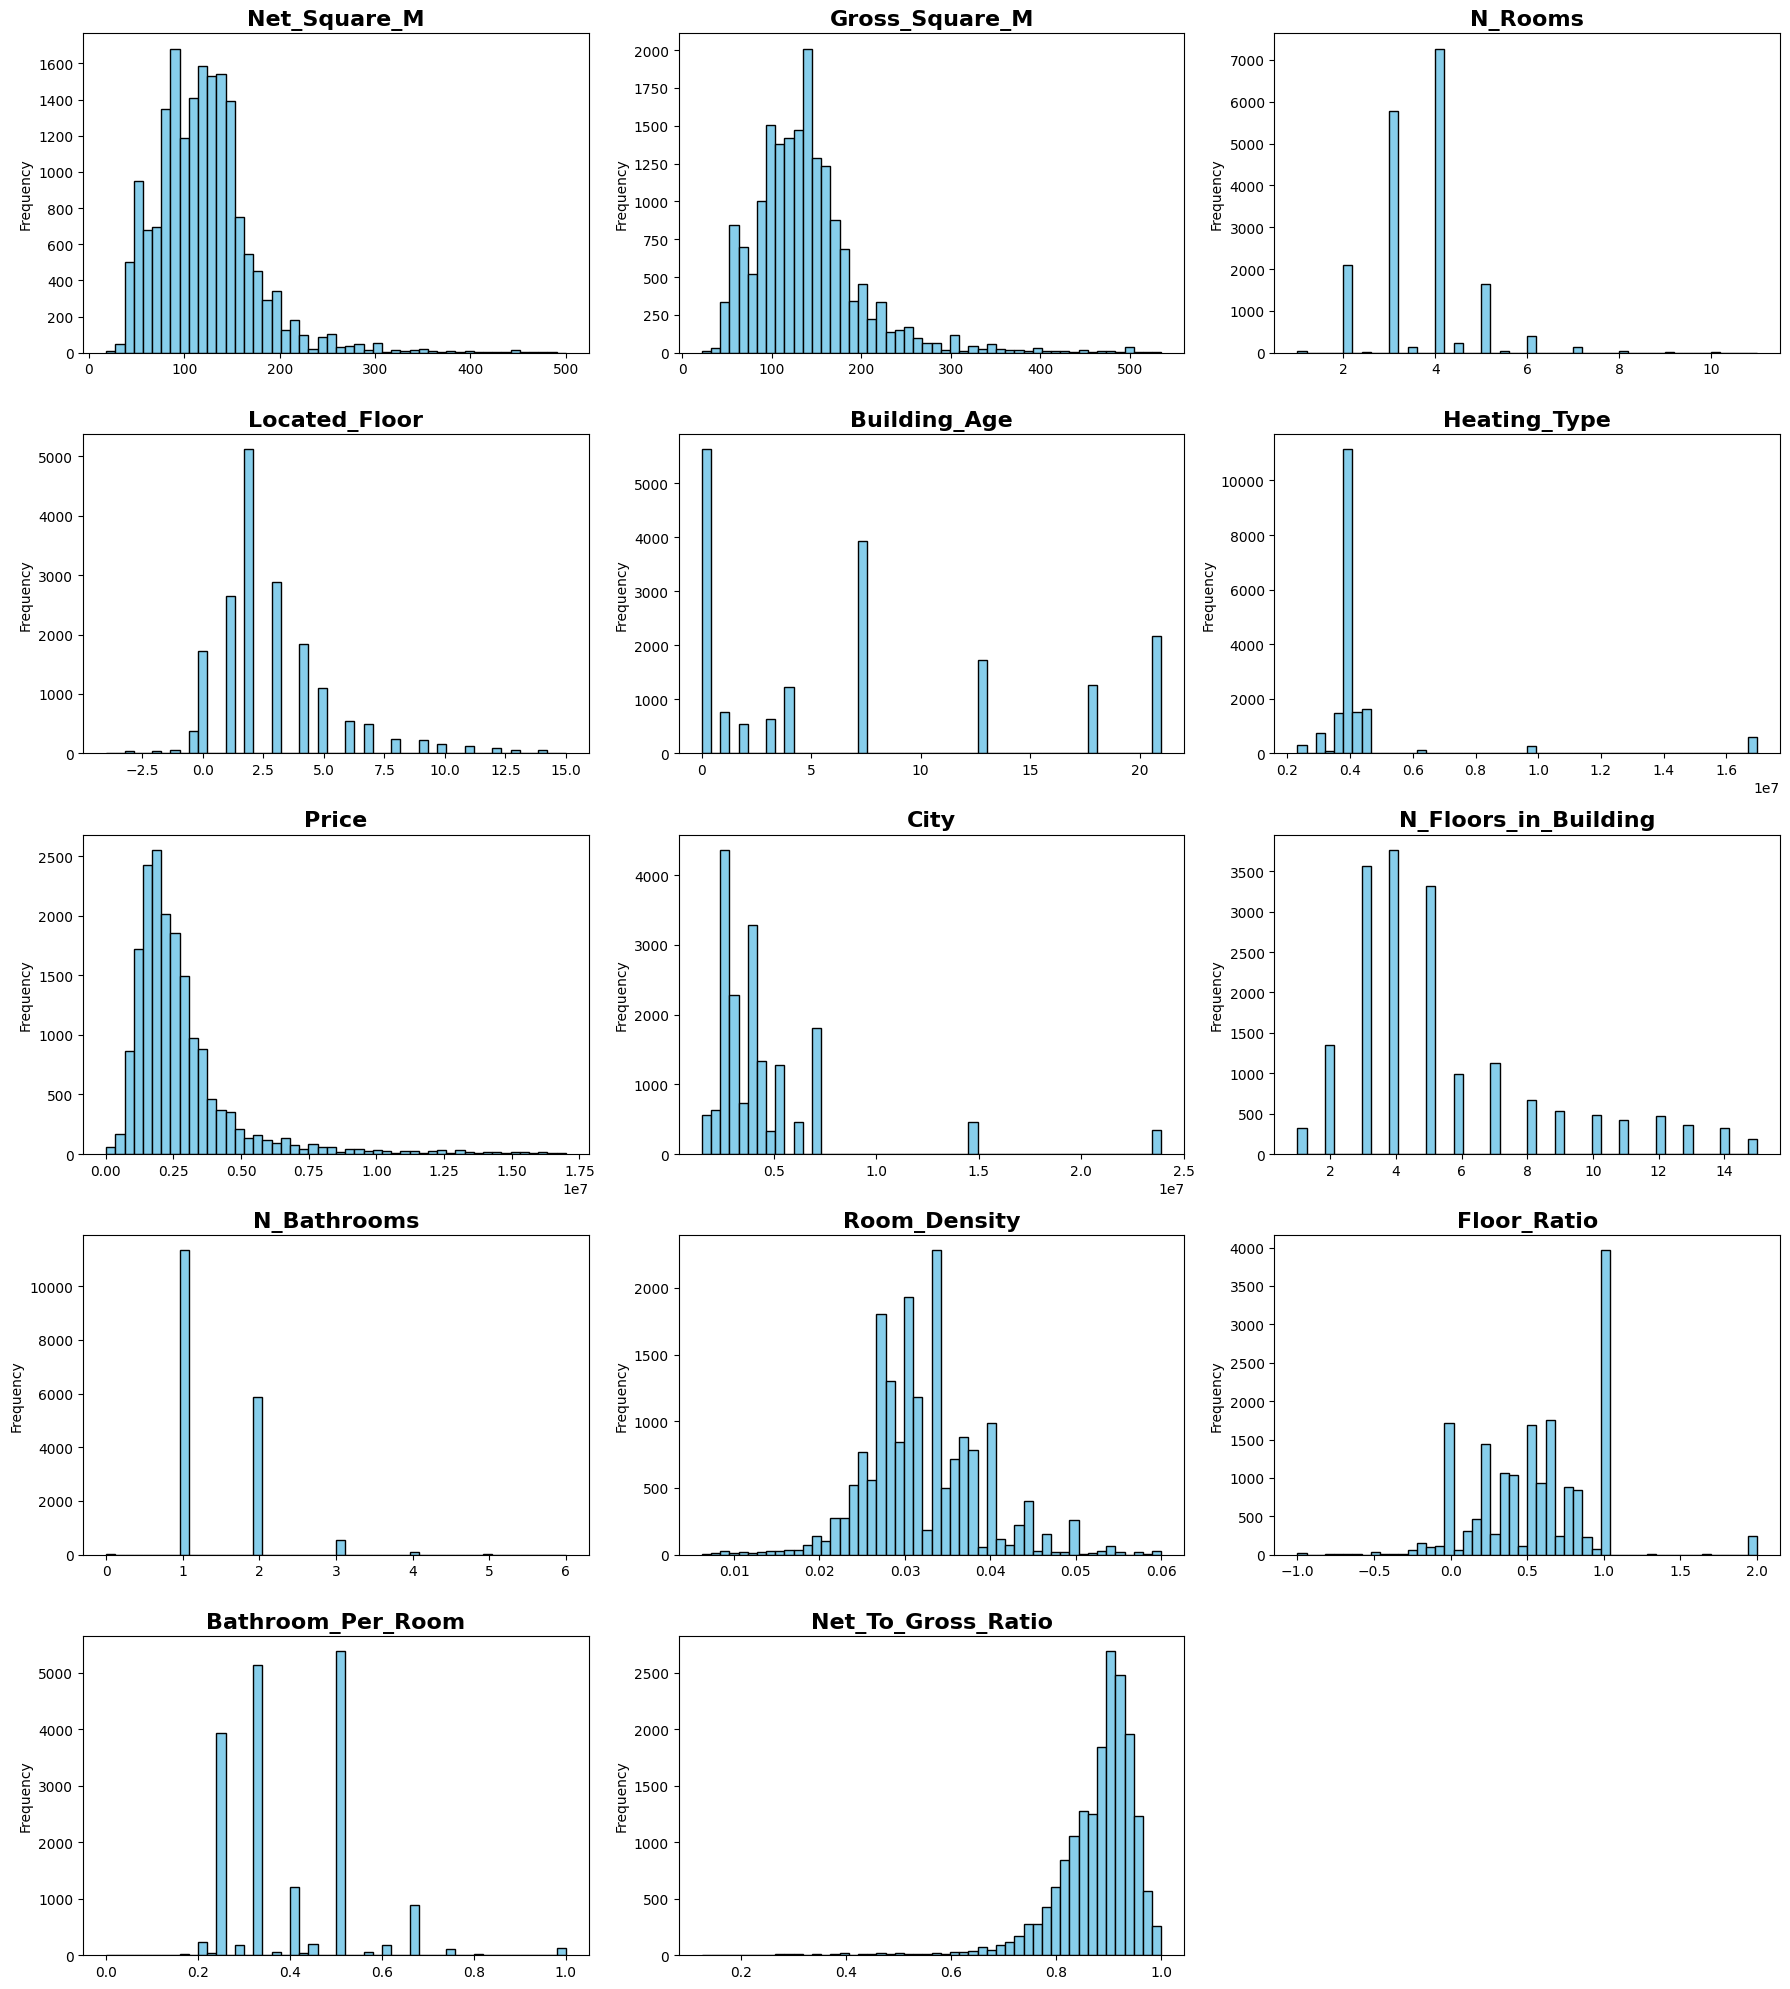

In [217]:
df_trimmed = df_featured.copy()

# Columns to trim 1% extremely large values from
cols_to_trim = ['Net_Square_M', 'Gross_Square_M', 'Price', 'Room_Density', 'Floor_Ratio', 'Bathroom_Per_Room']

for col in cols_to_trim:
    threshold = df_trimmed[col].quantile(0.99)  # 99th percentile
    original_count = df_trimmed.shape[0]
    df_trimmed = df_trimmed[df_trimmed[col] <= threshold]
    removed = original_count - df_trimmed.shape[0]
    print(f"{removed} (top 1%) samples removed from {col}")

# Plot distributions after trimming
plot_feature_distributions(df_trimmed)

##**Data Transformation**

In many real-world datasets, some numeric features are **highly skewed**—meaning their distribution is not symmetric and is stretched more to one side. This can negatively affect many machine learning models, especially those that assume normality (like linear regression).

To address this issue, we can apply **data transformations** to **normalize** the distribution of skewed features. Three commonly used methods are:

- **Logarithmic Transformation**:  
  Applying `log(x)` to compress large values and bring the distribution closer to a normal (bell-curve) shape.  
  Useful when the data contains **positive values only** and has a **long tail** on the right (like our `Price`, `Net_Square_M`, and `Gross_Square_M` features above.)

- **Root Transformation**:  
  Calculating `sqrt(x)` or any other root on the data compresses large values and desolves right-skewness as well.  

- **Exponential Transformation**:  
  Applying `exp(x)` or equivalently raising a small base (like `2^x`) can stretch the data on the right and pull up the left side.  
  Useful when the data contains **numbers bigger than 1** and the distribution is **left-skewed** (most values are piled up to the right side, with a long tail to the left), such as our `Net_To_Gross_Ratio`.  
  This transformation magnifies small differences between values close to 0 and helps balance the shape of the distribution.

These transformations help:
- Improve the **performance of models** that rely on distance or distribution assumptions.
- Reduce the **impact of outliers**.
- Make the feature values more **comparable and balanced**.

We will apply these transformations to specific columns in our dataset that show noticeable skewness, based on histogram plots or skewness metrics.

---

## **Code Insights**

We can apply **root transform** to columns that suffered from **right-skewness** and see the results — the distributions become beautifully aligned and much more symmetric.  

For the **Net_To_Gross_Ratio** column, which showed a clear **left-skewness**, we apply an **exponential transform**. But there is an issue: its values are between 0 and 1. Applying `exp(x)` directly in this range doesn’t stretch the data effectively. To solve this, we first **multiply all values by a constant (e.g., 6)** and then apply the exponential transform. This way, the range shifts from **0–1** to **0–6**, and the transformation behaves as desired.  

This is a general trick worth remembering:  
- For **log/root transform**, you can avoid taking the log of 0 or negative values by simply **adding a constant** to the whole column before transformation.  
- For **exp transform**, you can **scale up small values** before applying the exponential so that the transformation produces a meaningful spread.  

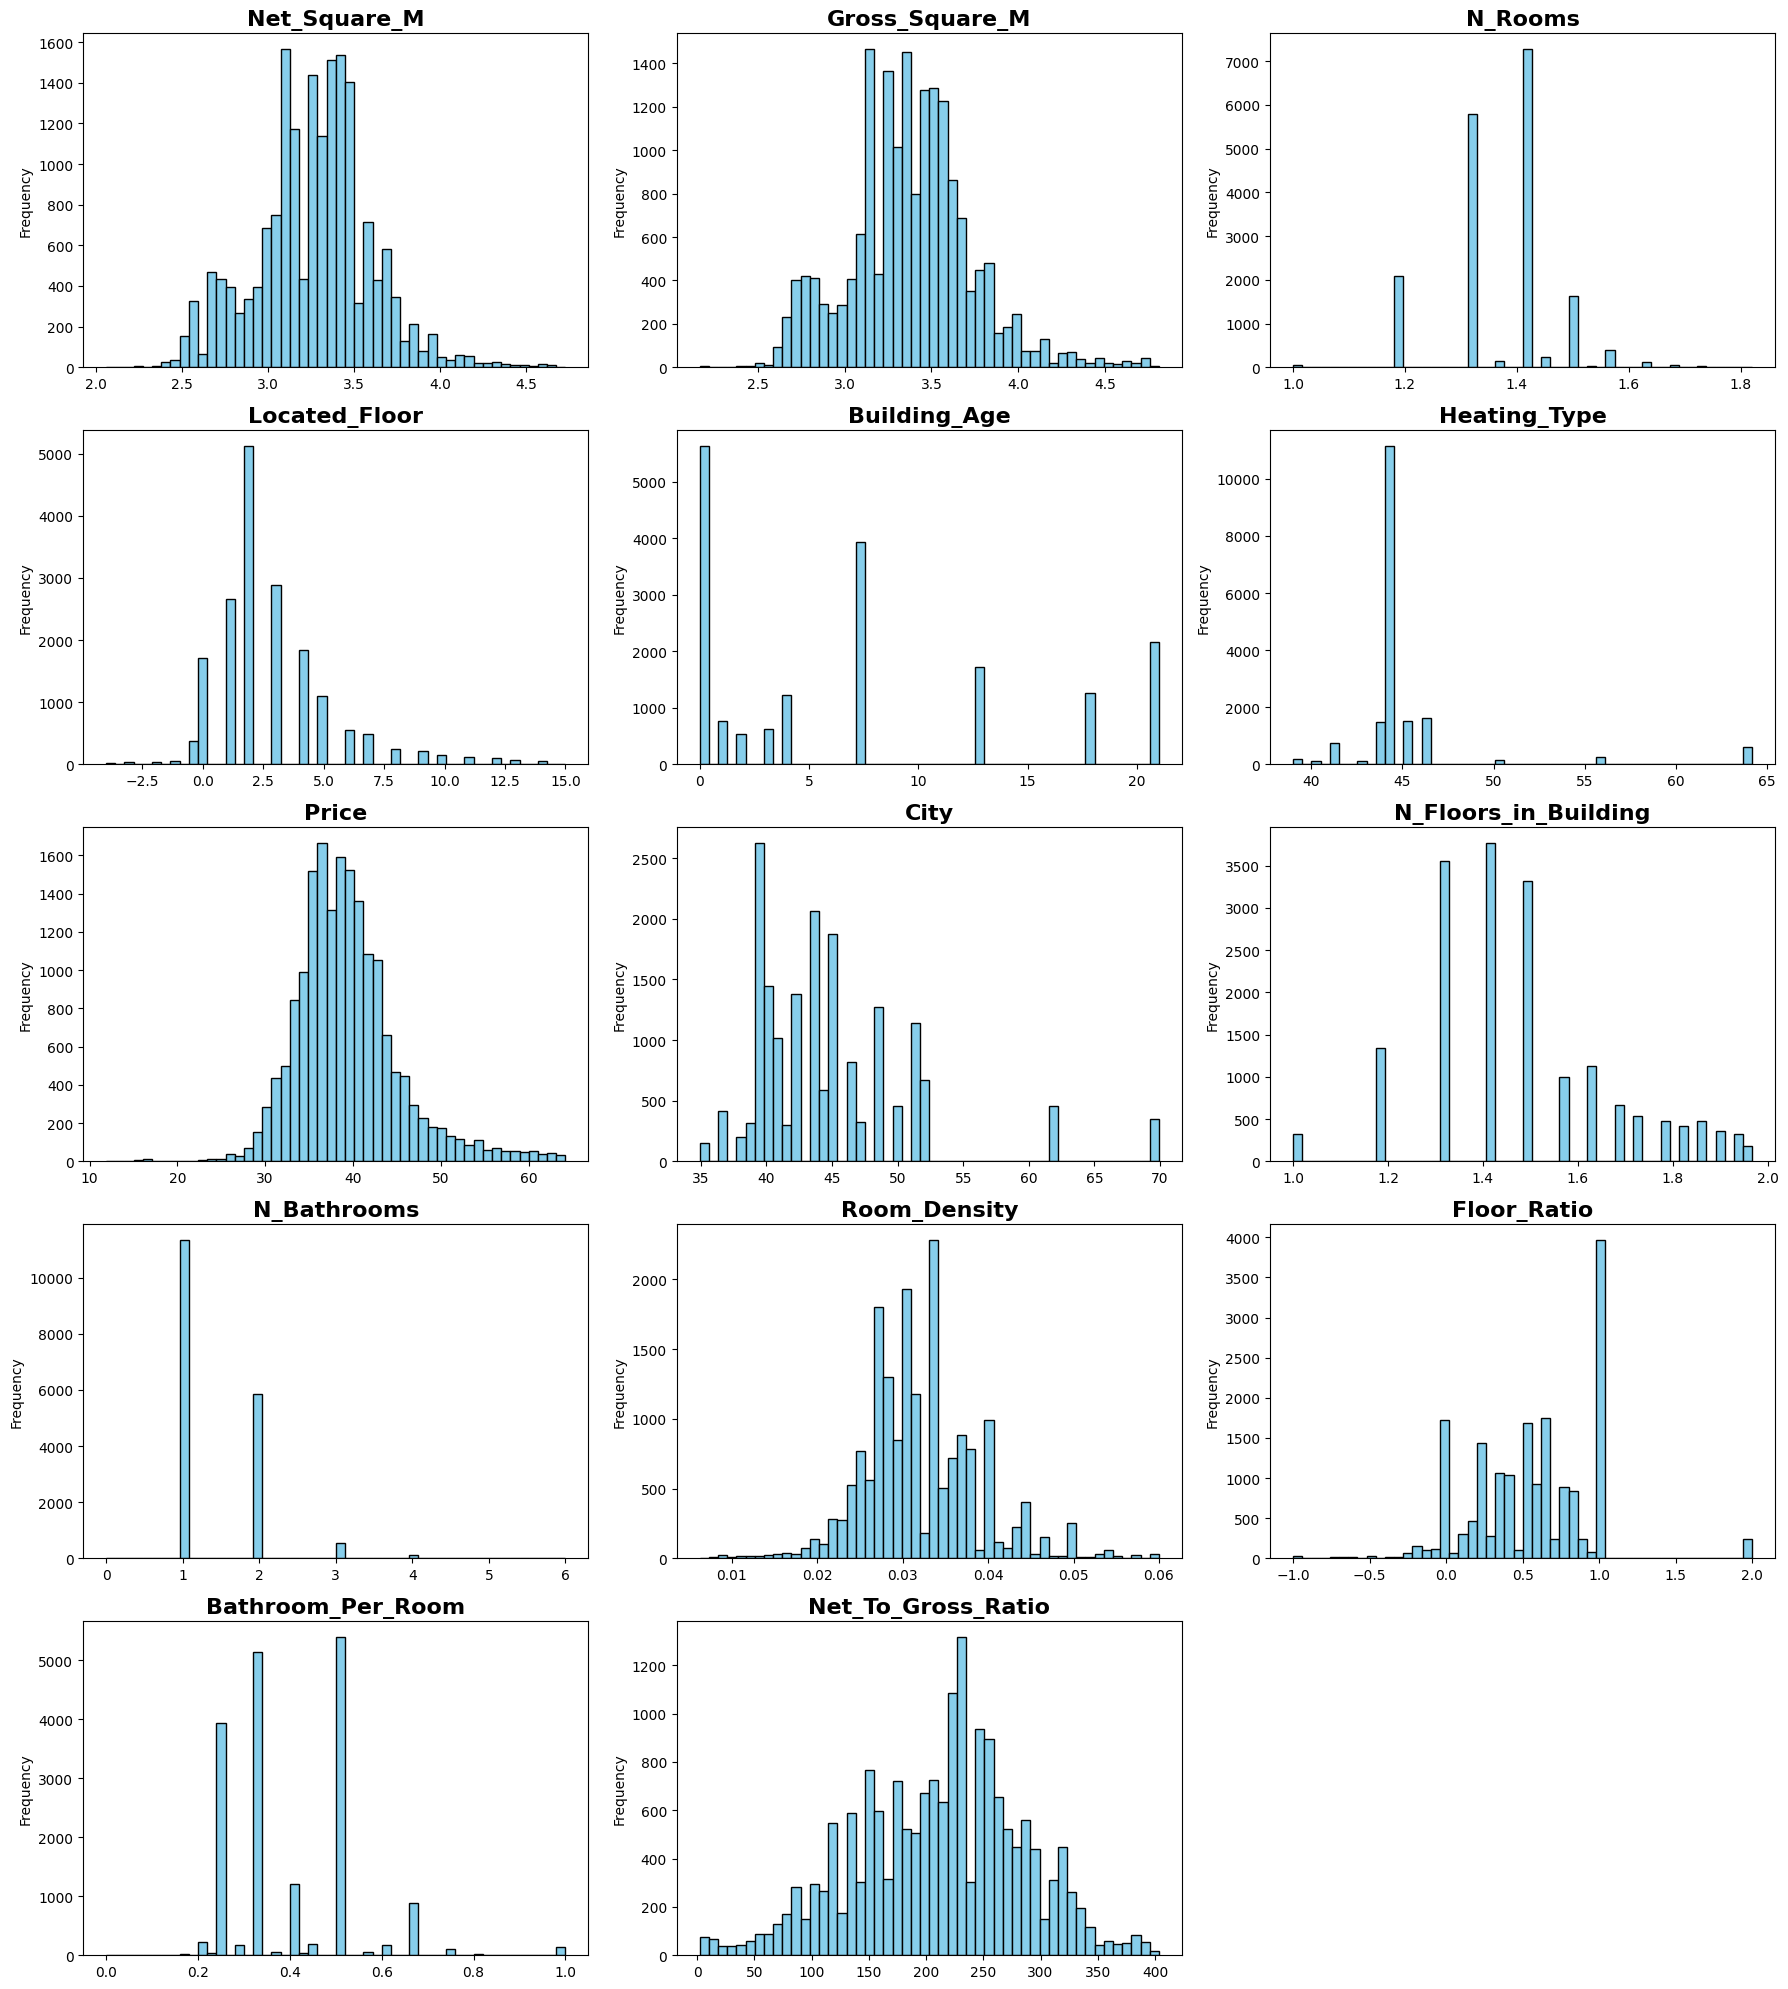

In [218]:
df_transformed = df_trimmed.copy()

# Columns to transform using root transformation
cols_to_transform = ['Net_Square_M', 'Gross_Square_M', 'N_Rooms', 'Heating_Type', 'Price', 'City', 'N_Floors_in_Building']

# apply 4th root transform for right-skewness
for col in cols_to_transform:
    df_transformed[col] = df_transformed[col]**(1/4)

# apply exp transform for left_skewness
df_transformed['Net_To_Gross_Ratio'] = np.exp(6 * df_transformed['Net_To_Gross_Ratio'])

# visualize distributions after transformation
plot_feature_distributions(df_transformed)

##**Feature Scaling**

In most datasets, features come in different units and scales — one feature might range from 0 to 1, while another ranges from 0 to 10,000.
This **difference in scale can confuse many machine learning algorithms**, especially those based on distance (like KNN, SVM) or gradient descent (like neural networks, logistic regression).

To bring all features to a similar scale, we use **feature scaling**.

### **Common Techniques**

* **Min-Max Scaling** (Normalization):
  Rescales values to a fixed range — usually between 0 and 1.
$$
  x_{scaled} = \frac{x - x_{min}}{x_{max} - x_{min}}
$$
  Good when your data doesn't have outliers.

* **Standardization** (Z-score Scaling):
  Centers the data around 0 with a standard deviation of 1.
  $$
  x_{scaled} = \frac{x - \mu}{\sigma}
  $$
  
  More robust to outliers and often preferred for most ML algorithms.

> Proper scaling can drastically improve the performance of your model by ensuring all features contribute fairly.

---

## **Code Insights**

As we notice, our features had wildly different scales: some were **binary** (0–1), others like `N_Rooms` ranged between 1–10, and features like `Price` reached into **millions or even billions**.  

From the previous chapter, we know this is dangerous: the model might mistakenly treat **large-scale features** as more important, overshadowing others. Transformations like log or exp make the ranges more moderate, but they still don’t guarantee **equal footing** for all features.  

That’s why we applied `StandardScaler` from `sklearn`. It rescales every feature to have **mean = 0** and **standard deviation = 1**, ensuring no single feature dominates just because of its scale.

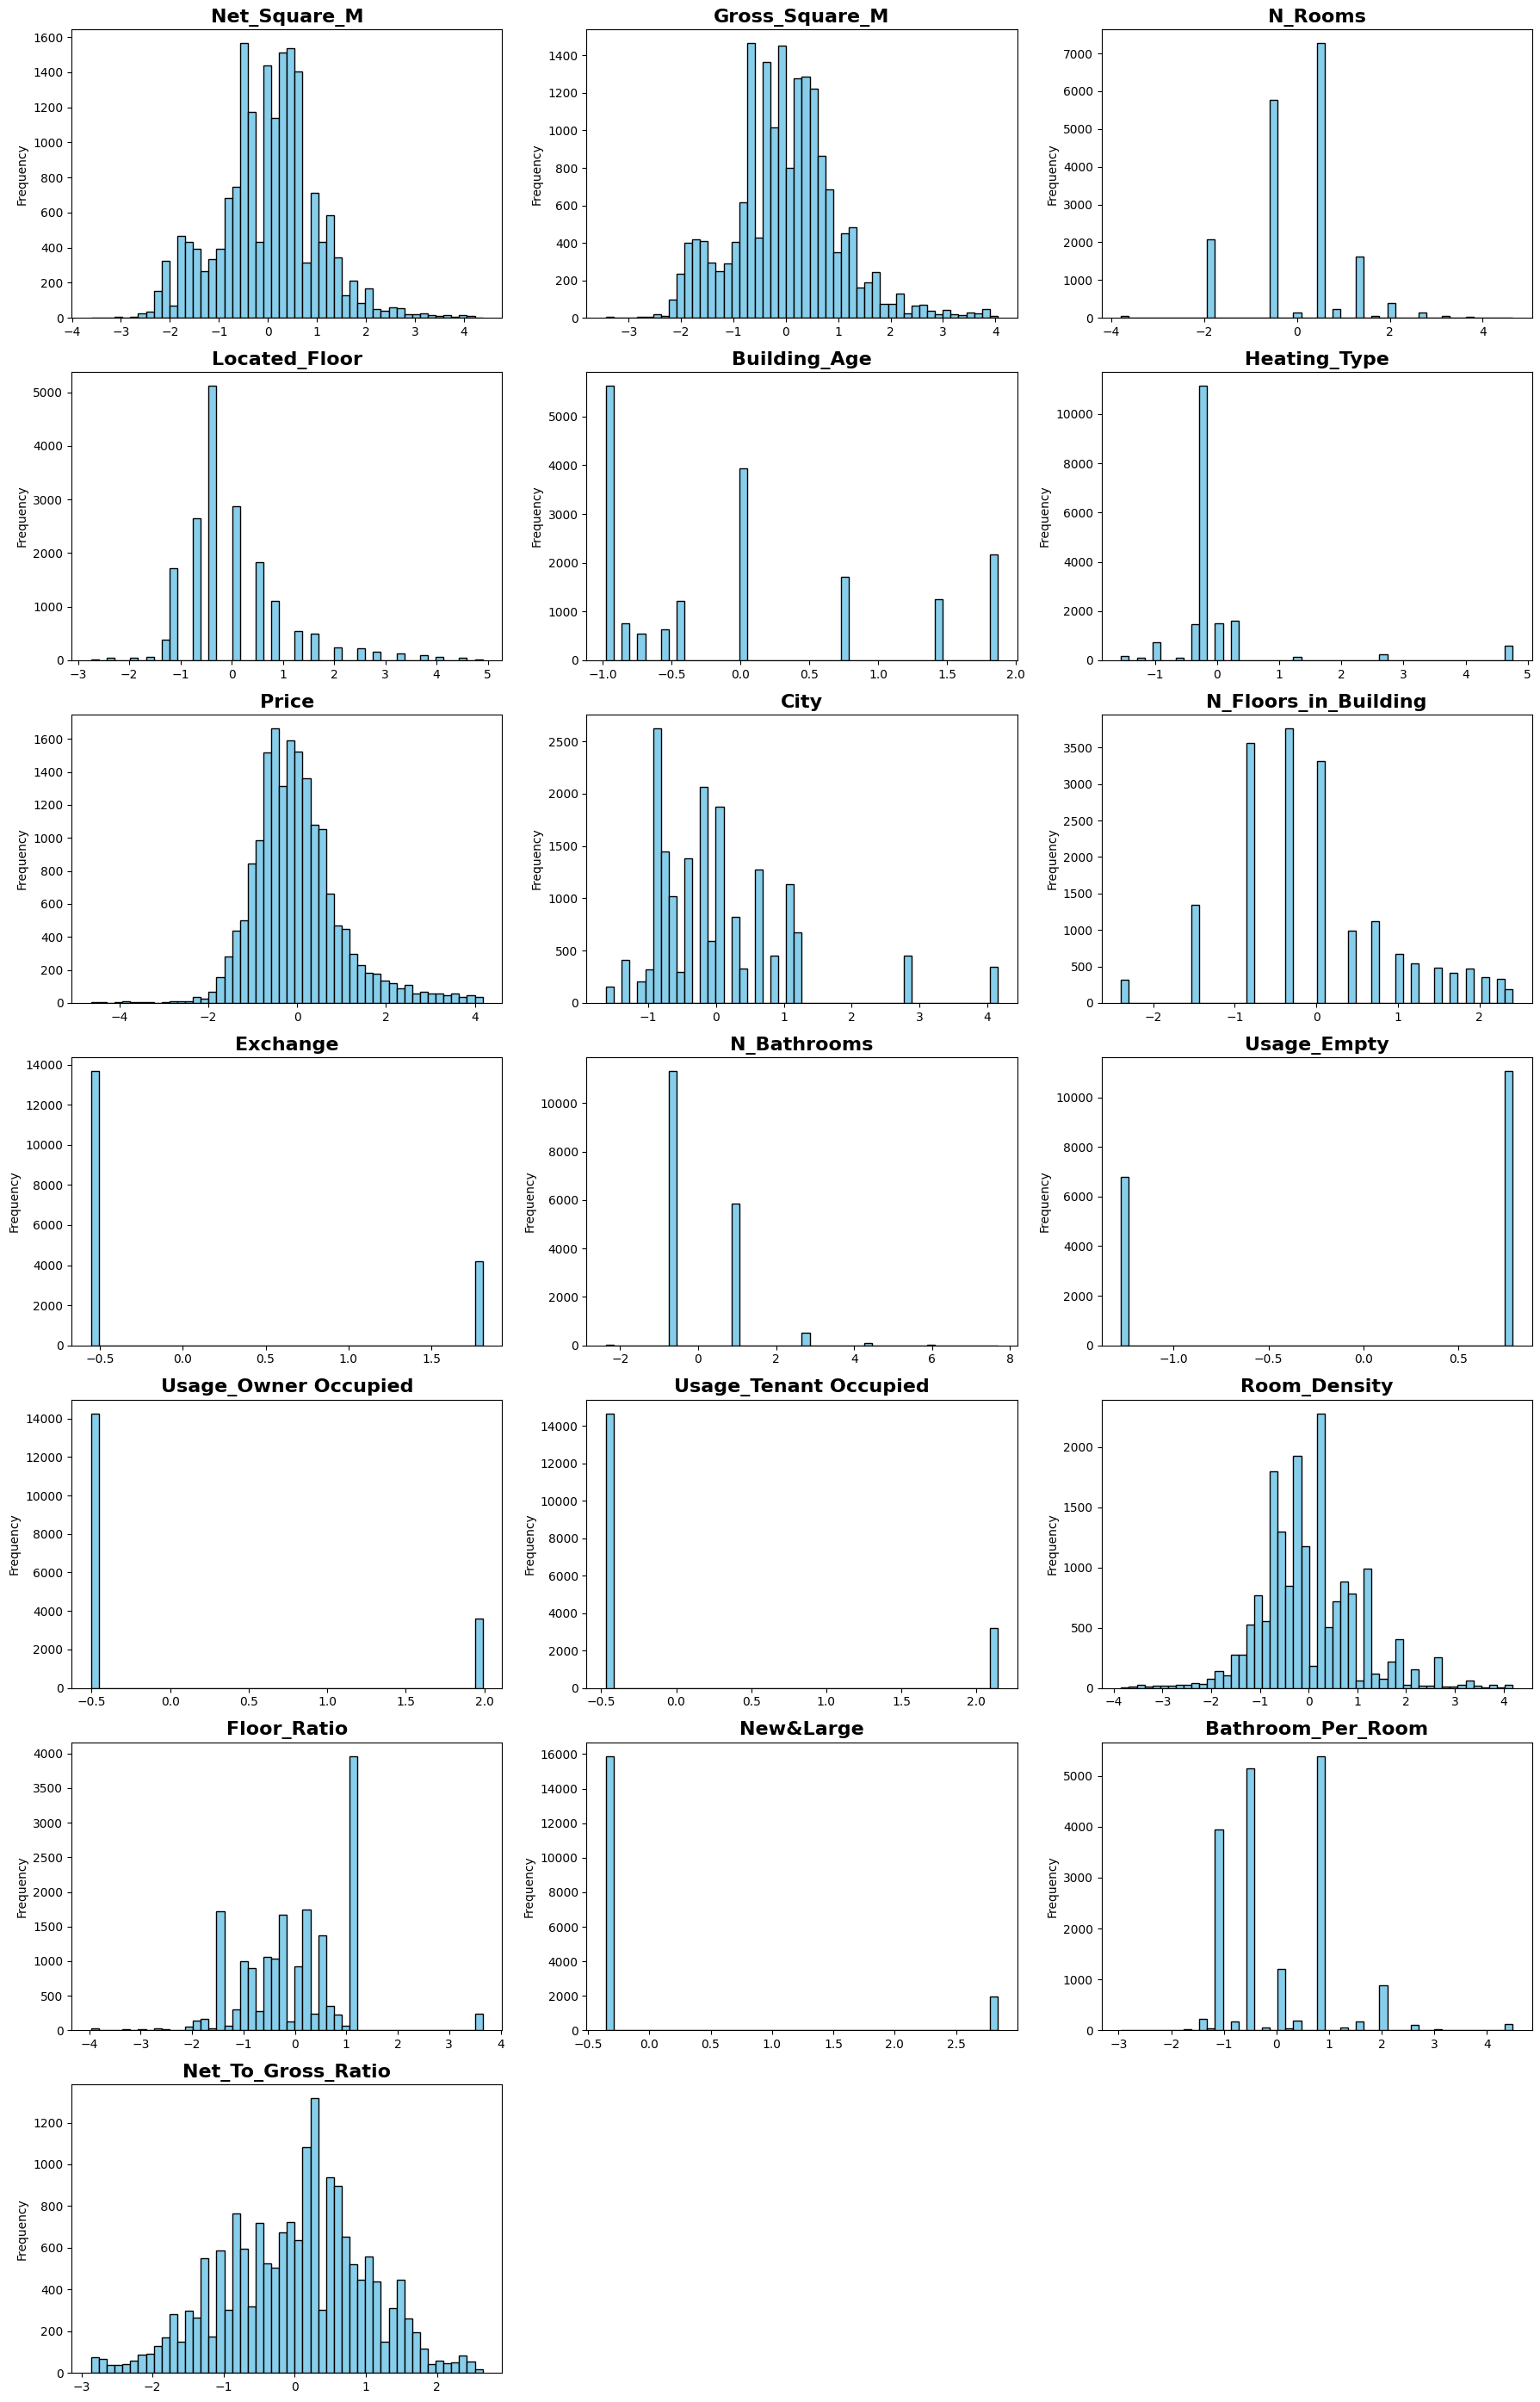

In [219]:
from sklearn.preprocessing import StandardScaler

df_scaled = df_transformed.copy()

# Save Price's mean and std for later
price_mean = df_scaled['Price'].mean()
price_std = df_scaled['Price'].std()

# Initialize scaler
scaler = StandardScaler()

# Fit and transform all columns
df_scaled[df_scaled.columns] = scaler.fit_transform(df_scaled[df_scaled.columns])

# Visualize distributions
plot_feature_distributions(df_scaled)

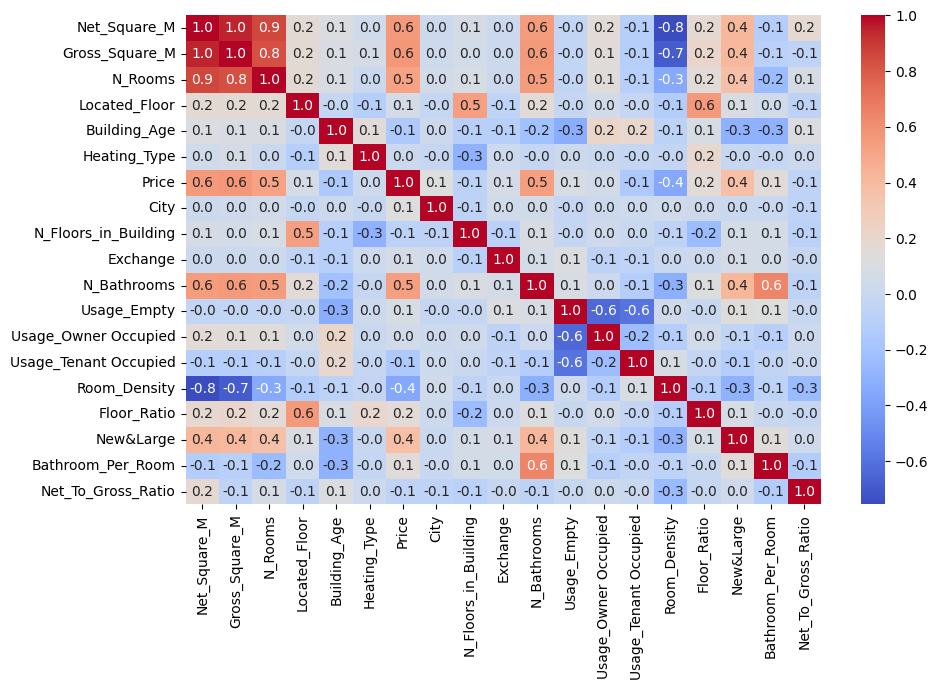

In [220]:
# Plot heatmap for a global correlation between all the features
plt.figure(figsize=(10, 7))
sns.heatmap(df_scaled.corr(), cmap='coolwarm', annot=True, fmt='.1f')
plt.tight_layout()
plt.show()

##**Train-Test Split**

During different rounds of training (epochs) a machine learning model, it's crucial to **evaluate how well it might perform on new, unseen data**. To simulate this, we divide our dataset into two parts: **training set** and **evaluation/testing set**.

If you train and test on the same data, your model might have **memorized** the patterns instead of learning them — eventually leading to a useless model. To prevent this, we split the data into:

* **Training set** → The model learns from this set
* **Testing set** → The model is evaluated on this (as if it's seeing new data)

This helps answer the question:

> "How well will my model perform in the real world with new data?"

### **How to Do It?**

We will first shuffle the whole dataset, and then split a small portion of it, and only use the larger portion for training. The smaller portion is only used to test the mode. The most common split is:

* **80% Training**
* **20% Testing**

This can vary based on the size of your dataset. If a dataset is very large, even a 90-10 split might be sufficient.

---

### **Important Notes**

* Always **shuffle** the data before splitting to avoid biased ordering (unless it's time-series data).
* If your dataset is **imbalanced** (e.g., in classification tasks), consider **stratified splitting** to preserve class proportions.

In [221]:
from sklearn.model_selection import train_test_split

# Determine the inputs and the output (Price)
X_values = df_scaled.drop(columns='Price')
y_values = df_scaled['Price']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(X_values, y_values, test_size=0.2, random_state=42)
print(f'Training Set: {X_train.shape}')
print(f'Test Set: {X_test.shape}')

Training Set: (14294, 18)
Test Set: (3574, 18)


## **Model Training & Evaluation**

At this point, we've walked through a complete mini-cycle of data preprocessing. We've cleaned our dataset, handled missing and duplicated values, encoded categorical features, scaled numeric ones, dealt with outliers, and applied necessary transformations for skewed distributions. After splitting the dataset into training and testing sets, we can now train a basic regression model (more on it in `S01_C00` of this course) and evaluate its performance in **predicting house prices**.

The results aren't so bad. Our model seems to have captured some underlying patterns in the data — it’s making reasonable predictions, though not perfect. That’s totally expected at this stage. With just a few hidden layers and limited tuning, we’ve already seen how even basic models can benefit from thoughtful preprocessing.

In [222]:
from sklearn.ensemble import RandomForestRegressor

# Create a random forest model
rf = RandomForestRegressor(
    n_estimators=90,
    random_state=42
)

# Train the model on X_train
rf.fit(X_train, y_train)
y_train_pred = rf.predict(X_train)

# Evaluate its performance on X_test
y_test_pred = rf.predict(X_test)

# Calculate Mean Squared Errors (MSE)
train_mse = np.mean((y_train - y_train_pred) ** 2)
test_mse = np.mean((y_test - y_test_pred) ** 2)
print(f"Train MSE = {train_mse:.4f}, Val MSE = {test_mse:.4f}")

Train MSE = 0.0477, Val MSE = 0.3361


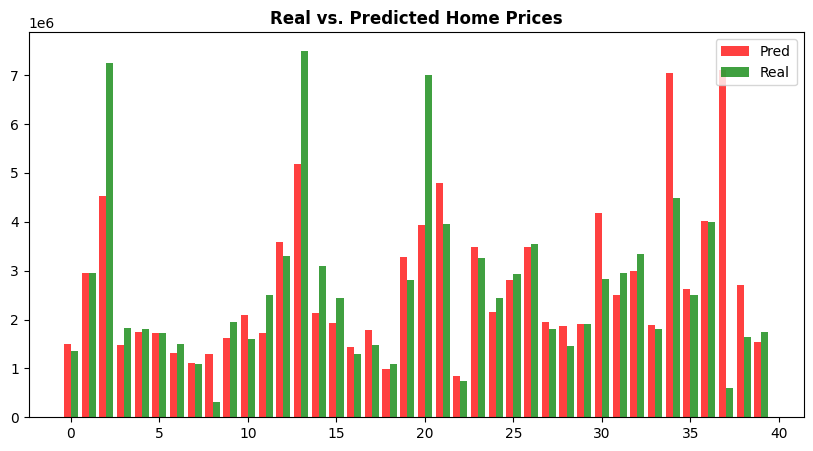

In [225]:
# Function to inverse scale the prices to real values
def inverse_scale(y):
  y_original = y * price_std + price_mean
  return y_original ** 4

real_rescaled = inverse_scale(y_test)
pred_rescaled = inverse_scale(y_test_pred)

# Compare real prices with predicted prices on a barplot
n_samples = 40
comb = pd.DataFrame({'Real':real_rescaled, 'Pred':pred_rescaled})
sample = comb.sample(n_samples,random_state=42)
indices = np.arange(n_samples)
plt.figure(figsize=(10,5))
plt.bar(indices-0.2,sample['Pred'],width=0.4,color='red',alpha=0.75,label='Pred')
plt.bar(indices+0.2,sample['Real'],width=0.4,color='green',alpha=0.75,label='Real')
plt.legend()
plt.title('Real vs. Predicted Home Prices', fontweight='bold')
plt.show()

## **Closing This Chapter**

In this chapter, we uncovered the art and science of **Data Preprocessing** — the unsung hero behind every powerful machine learning model. You learned how to transform raw, messy data into clean, meaningful information that models can actually learn from.

Every one of those steps protects us from feeding flawed, misleading data into our algorithms — ensuring that what our models learn is true, useful, and reliable.

---

###🚀 **What's next?**

> **Supervised Learning**

With clean, well-prepared data in hand, we’re ready to step into the heart of machine learning: teaching machines to make predictions. In the next section of our course (**Supervised Learning**), you’ll build your first real models, understand how they learn patterns, and discover how they solve real-world problems like classifying images, predicting prices, and more.

This is where your journey shifts from preparing data to unlocking its hidden knowledge — and teaching a machine to think with it. Let’s open this next door together.